# 天气图像分类

## 1. 背景

### 1.1 背景介绍

天气图像分类在自动驾驶、智慧城市、农业遥感、户外摄影分级等领域有广泛应用。通过对单张图片进行天气类别识别，可以辅助下游系统做出更合理的决策——例如自动驾驶系统在识别到雨雪天气后切换更保守的控制策略。

传统方法依赖手工特征（亮度直方图、HSV 通道统计、纹理描述子）配合 SVM/随机森林等分类器，在简单场景下尚可，但面对复杂户外场景（光照变化、构图差异、相机视角不同）时往往泛化能力不足。

本次比赛要求选手基于深度学习方法，对图片进行 4 分类，识别其属于的天气类型。

### 1.2 数据集展示

数据集来自多个独立来源整合，覆盖了不同光线、视角、地域和季节下的户外场景，涉及 4 个类别：**晴 (sunny)**、**阴 (cloudy)**、**雨 (rainy)**、**雪 (snowy)**。

图片均为 RGB 彩色图。训练集已统一 resize 为 224×224，建议在训练时从中再切一部分作为内部验证集（后台另有独立的评分集用于最终打分，选手不可见）。

数据集大致数量分布：

| 类别 | 训练集样本数 |
|------|--------------|
| sunny | ~1900 |
| cloudy | ~2100 |
| rainy | ~440 |
| snowy | ~400 |

## 2. 数据集分析和可视化

Duplicate key in file PosixPath('/usr/local/lib/python3.9/dist-packages/matplotlib/mpl-data/matplotlibrc'), line 801 ('font.family: sans-serif')
Duplicate key in file PosixPath('/usr/local/lib/python3.9/dist-packages/matplotlib/mpl-data/matplotlibrc'), line 802 ('font.sans-serif: SimHei')


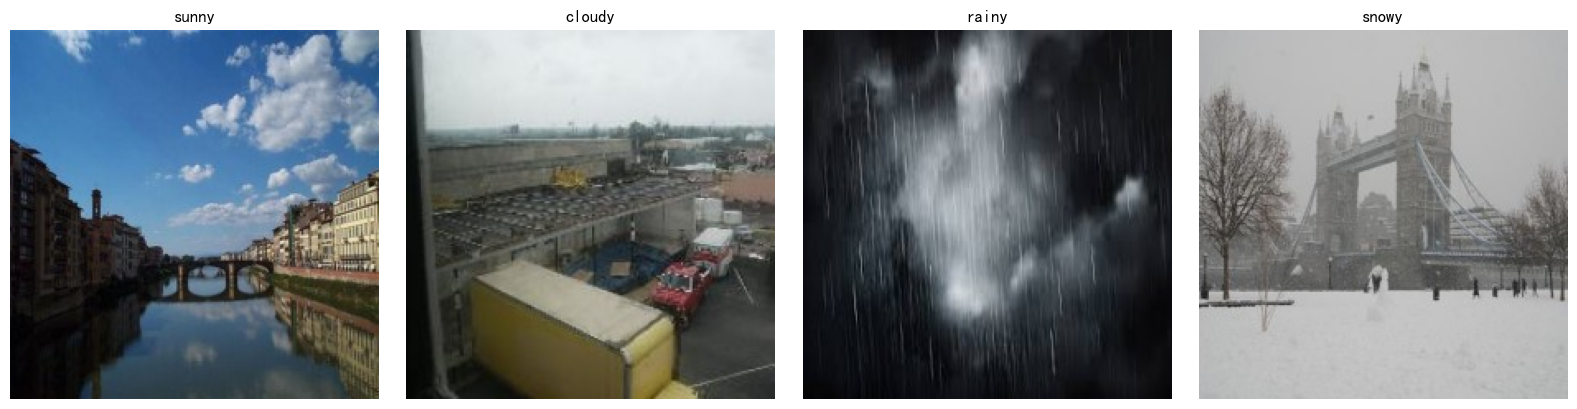

In [1]:
import cv2
import matplotlib.pyplot as plt
import random
import os

base_path = "/home/jovyan/work/datasets/6a39ed934d7b489daf5f80a4-momodel/train"
labels = ['sunny', 'cloudy', 'rainy', 'snowy']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, label in zip(axes, labels):
    label_dir = os.path.join(base_path, label)
    files = os.listdir(label_dir)
    img = cv2.imread(os.path.join(label_dir, random.choice(files)))
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(label)
    ax.axis('off')
plt.tight_layout()
plt.show()


## 3. 模型构建

本示例项目使用 PyTorch 构建、训练和评估深度学习模型。

### 3.1 导入库函数

In [2]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)


device: cpu


### 3.2 数据加载以及预处理

- 设置训练集路径，以及图片尺寸、batch_size。`val_ratio` 是从 train 中切出来的内部验证集比例，便于在训练过程中观察泛化表现。

In [3]:
train_dir = "/home/jovyan/work/datasets/6a39ed934d7b489daf5f80a4-momodel/train"

im_size = 224
batch_size = 32
num_classes = 4
val_ratio = 0.1  # 从 train 中切出内部验证集的比例


- 使用 `torchvision.datasets.ImageFolder` 按子目录名作为类别加载图片，归一化到 [0, 1]，并用 `random_split` 切出内部验证集。

In [4]:
tf = transforms.Compose([
    transforms.Resize((im_size, im_size)),
    transforms.ToTensor(),
])

full_set = datasets.ImageFolder(train_dir, transform=tf)
print('class_to_idx:', full_set.class_to_idx)

n_val = int(len(full_set) * val_ratio)
n_train = len(full_set) - n_val
train_set, val_set = random_split(
    full_set, [n_train, n_val],
    generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_set, batch_size=batch_size,
                          shuffle=True)
val_loader = DataLoader(val_set, batch_size=batch_size,
                        shuffle=False)

print('train size:', len(train_set), '  val size:', len(val_set))


class_to_idx: {'cloudy': 0, 'rainy': 1, 'snowy': 2, 'sunny': 3}
train size: 4500   val size: 499


### 3.3 模型搭建

继承 `nn.Module` 实现一个简单的 CNN baseline。

选手可在此基础上替换为 `torchvision.models` 中的 ResNet、EfficientNet 等更深的网络，或加入数据增强、迁移学习等技巧。

In [5]:
class WeatherCNN(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, kernel_size=3), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(128 * 26 * 26, 256), nn.ReLU(inplace=True),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model = WeatherCNN(num_classes=num_classes).to(device)
print(model)


WeatherCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
    (7): ReLU(inplace=True)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.5, inplace=False)
    (2): Linear(in_features=86528, out_features=256, bias=True)
    (3): ReLU(inplace=True)
    (4): Linear(in_features=256, out_features=4, bias=True)
  )
)


## 4. 模型训练与评估

### 4.1 模型训练

可在 notebook 中直接训练，也可以将代码迁移到 train.py 在 GPU 上训练。

训练完成后请将模型保存到 `results/` 文件夹下。

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
epochs = 10

def evaluate(model, loader):
    model.eval()
    total, correct, loss_sum = 0, 0, 0.0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss_sum += criterion(out, y).item() * x.size(0)
            correct += (out.argmax(dim=1) == y).sum().item()
            total += x.size(0)
    return loss_sum / total, correct / total

for epoch in range(1, epochs + 1):
    model.train()
    running_loss, total, correct = 0.0, 0, 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * x.size(0)
        correct += (out.argmax(dim=1) == y).sum().item()
        total += x.size(0)
    val_loss, val_acc = evaluate(model, val_loader)
    print(f'Epoch {epoch}/{epochs}  '
          f'train_loss={running_loss/total:.4f}  train_acc={correct/total:.4f}  '
          f'val_loss={val_loss:.4f}  val_acc={val_acc:.4f}')

os.makedirs('/home/jovyan/work/results', exist_ok=True)
torch.save(model.state_dict(), '/home/jovyan/work/results/model_sample.pth')


### 4.2 模型评估

本次比赛使用 **F1 macro** 作为评估指标。

由于数据集存在类别不平衡（rainy 和 snowy 样本明显少于 sunny 和 cloudy），macro F1 会对所有类别一视同仁，逼使模型对少样本类别也保持较高识别能力。

下面在切出来的内部验证集（`val_loader`）上计算 F1 macro。

In [6]:
from sklearn.metrics import f1_score, classification_report

model.load_state_dict(torch.load('/home/jovyan/work/results/model_sample.pth',
                                  map_location=device))
model.eval()

y_true, y_pred = [], []
with torch.no_grad():
    for x, y in val_loader:
        x = x.to(device)
        out = model(x)
        pred = out.argmax(dim=1).cpu().numpy()
        y_true.extend(y.numpy())
        y_pred.extend(pred)

idx_to_class = {v: k for k, v in full_set.class_to_idx.items()}
target_names = [idx_to_class[i] for i in range(num_classes)]

print('F1 macro:', f1_score(y_true, y_pred, average='macro'))
print(classification_report(y_true, y_pred, target_names=target_names))


F1 macro: 0.6617653033586132
              precision    recall  f1-score   support

      cloudy       0.75      0.76      0.75       207
       rainy       0.50      0.29      0.37        45
       snowy       0.75      0.62      0.68        39
       sunny       0.81      0.90      0.85       208

    accuracy                           0.76       499
   macro avg       0.70      0.64      0.66       499
weighted avg       0.75      0.76      0.75       499



### 4.3 模型测试

加载训练好的模型，对单张图片进行推理。

In [8]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

model.load_state_dict(torch.load('/home/jovyan/work/results/model_sample.pth',
                                  map_location=device))
model.eval()

img = cv2.imread('/home/jovyan/work/datasets/6a39ed934d7b489daf5f80a4-momodel/train/sunny/sunny_00009.jpg', 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

img_in = cv2.resize(img, (224, 224)).astype(np.float32) / 255.0
img_in = np.transpose(img_in, (2, 0, 1))[np.newaxis, :, :, :]
img_in = torch.from_numpy(img_in).to(device)

with torch.no_grad():
    pred = model(img_in)

label = ['cloudy', 'rainy', 'snowy', 'sunny']
print('预测结果: ' + label[int(torch.argmax(pred, dim=1).item())])


预测结果: sunny


## 5. 评分

**注意：**

1. 你可以在我们准备好的接口中实现模型（也可以修改函数接口），也可以自己实现深度学习模型，写好代码后可以在 Py 文件中使用 GPU 进行模型训练。
2. 在训练模型等过程中如果需要**保存数据、模型**等请写到 **results** 文件夹，如果采用 [离线任务](https://momodel.cn/docs/#/zh-cn/%E5%9C%A8GPU%E6%88%96CPU%E8%B5%84%E6%BA%90%E4%B8%8A%E8%AE%AD%E7%BB%83%E6%9C%BA%E5%99%A8%E5%AD%A6%E4%B9%A0%E6%A8%A1%E5%9E%8B) 请务必将模型保存在 **results** 文件夹下。
3. 训练出自己最好的模型后，先按照下列 cell 操作方式实现 NoteBook 加载模型测试；请测试通过再进行【系统测试】。
4. 请填写你的模型路径及名称并补充 `predict()` 函数以实现预测。
5. 点击左侧栏提交结果后点击生成文件则需勾选 `predict()` 函数的 cell。
6. 请导入必要的包和第三方库（包括此文件中曾经导入过的）。
7. 请加载你认为训练最佳的模型，即请按要求填写模型路径。
8. 测试提交时服务端会调用 `predict()` 函数，请不要修改该函数的输入输出及其数据类型。
9. 最终评分指标为 **F1 macro**。

===============  **模型预测代码答题区域**  ===============

在下方的代码块中编写 **模型预测 predict()** 部分的代码，请勿在别的位置作答。

提交文件 `main.py` 中需要包含 `predict()` 函数，提交文件样例参考 `main.py`。

In [ ]:
# -------------------------- 请加载最满意的模型 ---------------------------
# 加载模型(请加载你认为的最佳模型)
# 加载模型,加载请注意 model_path 是相对路径, 与当前文件同级。
# 如果你的模型是在 results 文件夹下的 my_model.pth 模型，则 model_path = './results/my_model.pth'
path = None

# 加载模型
model = None


def predict(X):
    """
    模型预测
    param：
        X : np.ndarray，由 cv2.imread 读取的图片数据，shape(224,224,3)。
    return：
        y_predict : str, 数据 label，取值为 'sunny', 'cloudy', 'rainy', 'snowy' 之一。
    """

    # -------------------------- 实现模型预测部分的代码 ---------------------------
    y_predict = None

    # -------------------------------------------------------------------------

    return y_predict


======================  **测试提交函数示例**  ======================

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import cv2

label = ['cloudy', 'rainy', 'snowy', 'sunny']
im_size = 224
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


class WeatherCNN(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, kernel_size=3), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(128 * 26 * 26, 256), nn.ReLU(inplace=True),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


model = WeatherCNN(num_classes=len(label)).to(device)
model.load_state_dict(torch.load('./results/model_sample.pth',
                                  map_location=device))
model.eval()


def predict(X):
    """
    模型预测
    param：
        X : np.ndarray，由 cv2.imread 读取的图片数据，shape(224,224,3)。
    return：
        y_predict : str, 数据 label，取值为 'sunny', 'cloudy', 'rainy', 'snowy' 之一。
    """
    X = cv2.resize(X, (im_size, im_size))
    X = X.astype(np.float32) / 255.0
    X = np.transpose(X, (2, 0, 1))[np.newaxis, :, :, :]
    X = torch.from_numpy(X).to(device)

    with torch.no_grad():
        prediction = model(X)
    y_predict = label[int(torch.argmax(prediction, dim=1).item())]
    return y_predict
